Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from kmodes.kmodes import KModes
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier



EDA (Exploratory Data Analysis)

Loading Dataset

In [2]:
df= pd.read_csv('cardio_train.csv')

Top 20 Columns of Dataset

In [3]:
df.head(20)

,id,age(years),gender,height,weight,ap_lo,ap_hi,cholesterol,smoke,alco,gluc,active,cardio
0,0,50,2,168,62.0,80,110,1,0,0,1,1,0
1,1,55,1,156,85.0,90,140,3,0,0,1,1,1
2,2,52,1,165,64.0,70,130,3,0,0,1,0,1
3,3,48,2,169,82.0,100,150,1,0,0,1,1,1
4,4,48,1,156,56.0,60,100,1,0,0,1,0,0
5,8,60,1,151,67.0,80,120,2,0,0,2,0,0
6,9,61,1,157,93.0,80,130,3,0,0,1,1,0
7,12,62,2,178,95.0,90,130,3,0,0,3,1,1
8,13,48,1,158,71.0,70,110,1,0,0,1,1,0
9,14,54,1,164,68.0,60,110,1,0,0,1,0,0


Bottom Columns of Dataset

In [4]:
print(df.tail())

          id  age(years)  gender  height  weight  ap_lo  ap_hi  cholesterol  \
69995  99993          53       2     168    76.0     80    120            1   
69996  99995          62       1     158   126.0     90    140            2   
69997  99996          52       2     183   105.0     90    180            3   
69998  99998          61       1     163    72.0     80    135            1   
69999  99999          56       1     170    72.0     80    120            2   

       smoke  alco  gluc  active  cardio  
69995      1     0     1       1       0  
69996      0     0     2       1       1  
69997      0     1     1       0       1  
69998      0     0     2       0       1  
69999      0     0     1       1       0  


Information related to the dataset i.e If any null values exist,number of columns,name of columns,number of rows,Data type of each column

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age(years)   70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_lo        70000 non-null  int64  
 6   ap_hi        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  gluc         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


Dimension and Shape of data

In [6]:
dimension=df.ndim
print('Dimension',dimension)
print('Rows and Columns',df.shape)

Dimension 2
Rows and Columns (70000, 13)


Description of the dataset i.e mean,number of each column,standard deviation,min to max values

In [7]:
df.describe()

,id,age(years),gender,height,weight,ap_lo,ap_hi,cholesterol,smoke,alco,gluc,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,53.338686,1.349571,164.359229,74.205690,96.630414,128.817286,1.366871,0.088129,0.053771,1.226457,0.803729,0.499700
std,28851.302323,6.765294,0.476838,8.210126,14.395757,188.472530,154.011419,0.680250,0.283484,0.225568,0.572270,0.397179,0.500003
min,0.000000,30.000000,1.000000,55.000000,10.000000,-70.000000,-150.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,25006.750000,48.000000,1.000000,159.000000,65.000000,80.000000,120.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
50%,50001.500000,54.000000,1.000000,165.000000,72.000000,80.000000,120.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,74889.250000,58.000000,2.000000,170.000000,82.000000,90.000000,140.000000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,99999.000000,65.000000,2.000000,250.000000,200.000000,11000.000000,16020.000000,3.000000,1.000000,1.000000,3.000000,1.000000,1.000000


In [8]:
df.mode()

,id,age(years),gender,height,weight,ap_lo,ap_hi,cholesterol,smoke,alco,gluc,active,cardio
0,0,56.0,1.0,165.0,65.0,80.0,120.0,1.0,0.0,0.0,1.0,1.0,0.0
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69996,99995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69997,99996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69998,99998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.median()

id             50001.5
age(years)        54.0
gender             1.0
height           165.0
weight            72.0
ap_lo             80.0
ap_hi            120.0
cholesterol        1.0
smoke              0.0
alco               0.0
gluc               1.0
active             1.0
cardio             0.0
dtype: float64

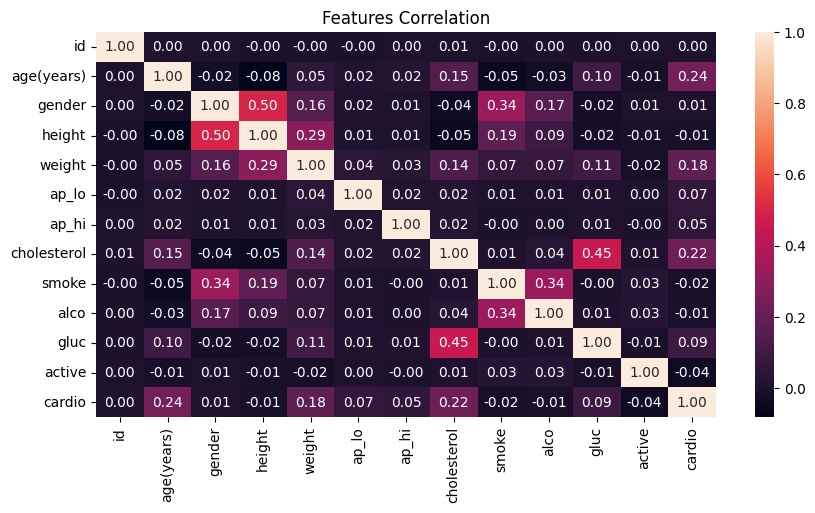

In [10]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.title("Features Correlation")
plt.show()

In [11]:
print('Checking if there is any duplication in data',df.duplicated().sum())


Checking if there is any duplication in data 0


In [12]:
print('Checking if there is null row exist',df.isnull().sum().sum())

Checking if there is null row exist 0


Box plot and Count of each cartegorical Column

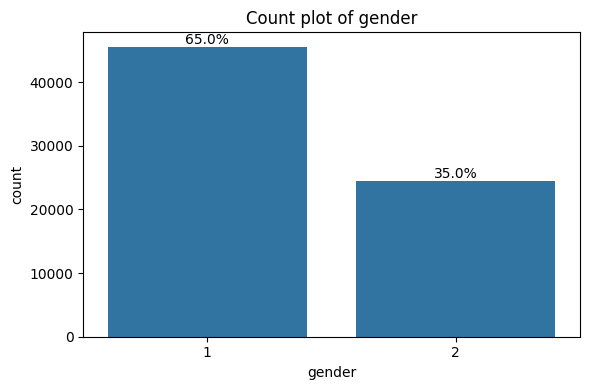

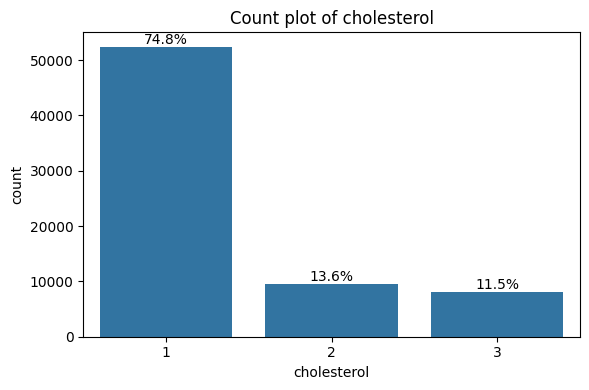

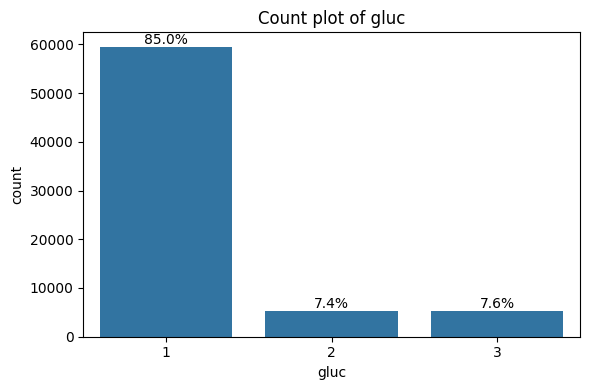

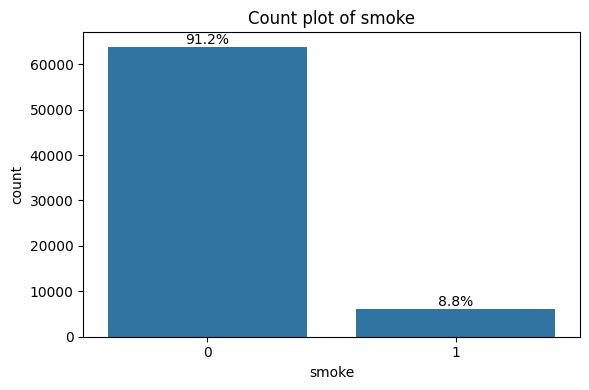

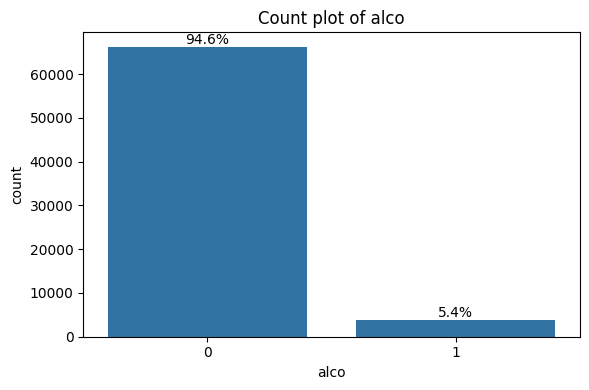

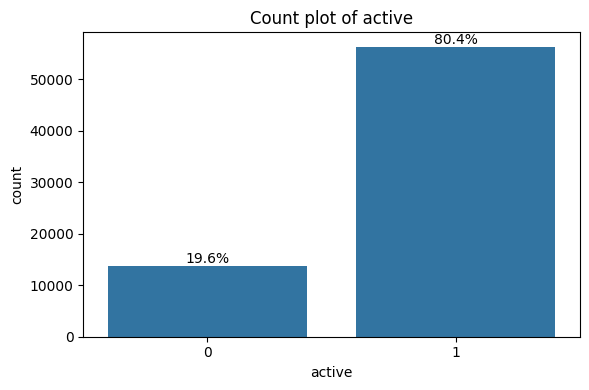

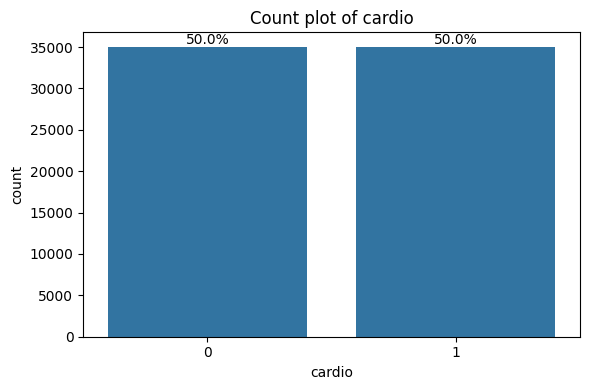

In [13]:
cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    ax = sns.countplot(x=col, data=df)
    plt.title(f'Count plot of {col}')
    
    total = len(df)
    percent_labels = []
    for p in ax.patches:
     percent = (p.get_height() / total) * 100
     percent_labels.append(f'{percent:.1f}%')

    ax.bar_label(ax.containers[0], labels=percent_labels)
   
    
    plt.tight_layout()
    plt.show()


Outlier Detection

In [14]:
import numpy as np
import pandas as pd

outliers = {}
for col in df.select_dtypes(include=np.number):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.975)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outliers[col] = ((df[col] < low) | (df[col] > high)).sum()


print(pd.DataFrame.from_dict(outliers, orient='index', columns=['Outlier Count']))


             Outlier Count
id                       0
age(years)               0
gender                   0
height                  92
weight                  13
ap_lo                 1095
ap_hi                  228
cholesterol              0
smoke                    0
alco                     0
gluc                     0
active               13739
cardio                   0


In [15]:
print(pd.DataFrame.from_dict(outliers, orient='index', columns=['Total Ouliers']).sum())

Total Ouliers    15167
dtype: int64


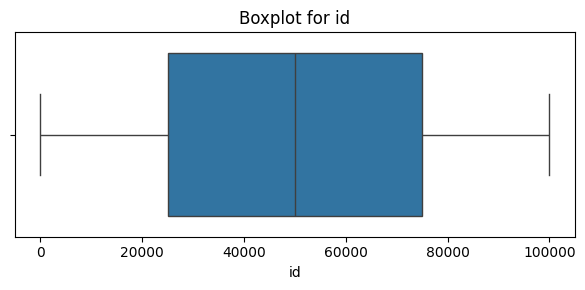

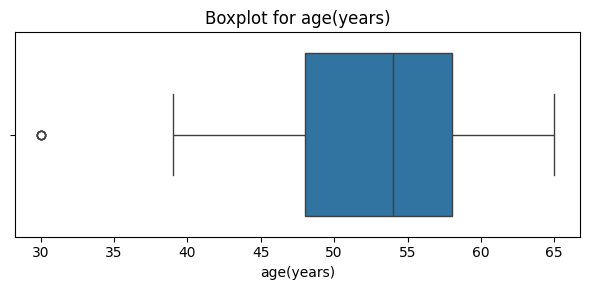

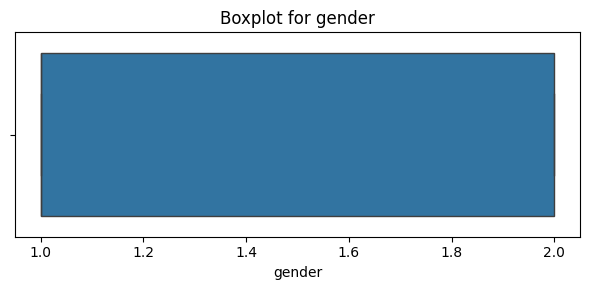

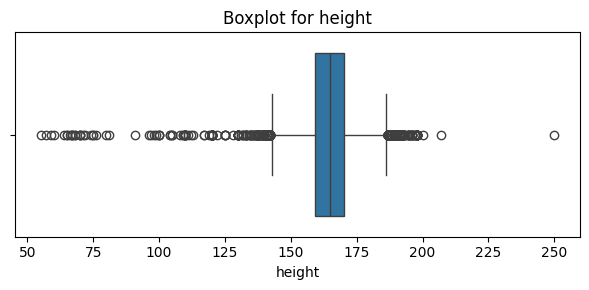

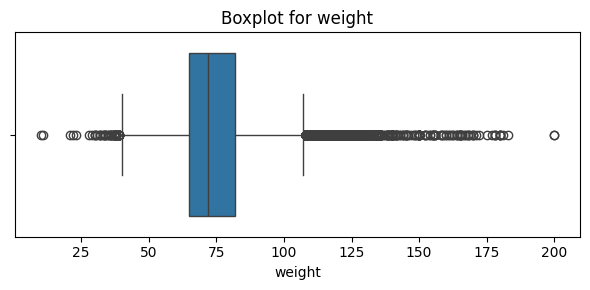

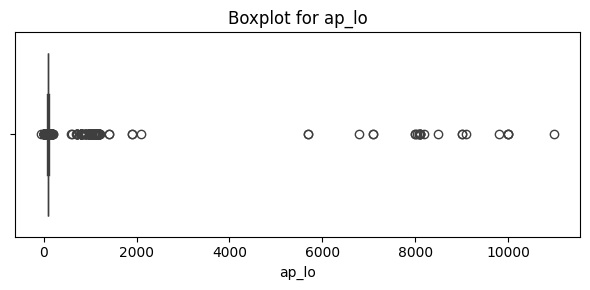

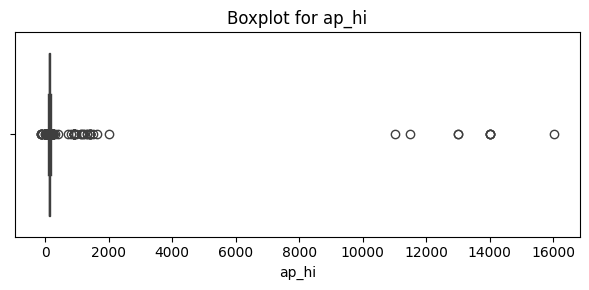

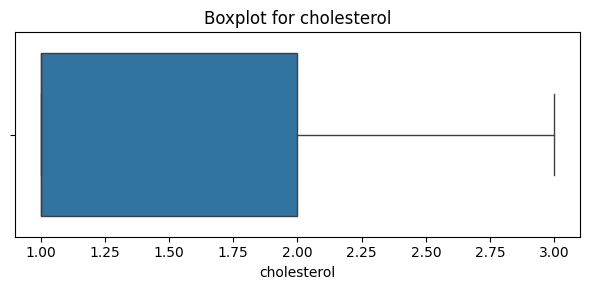

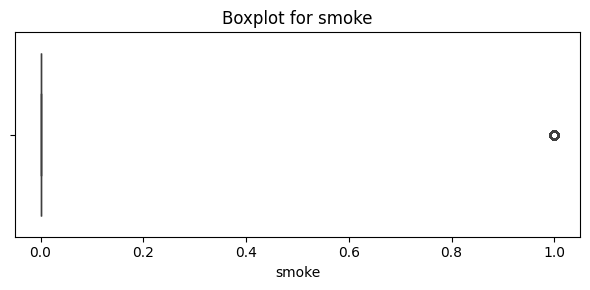

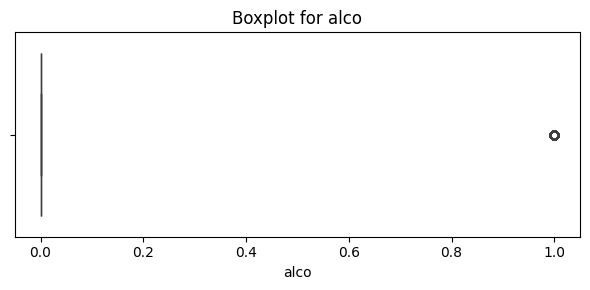

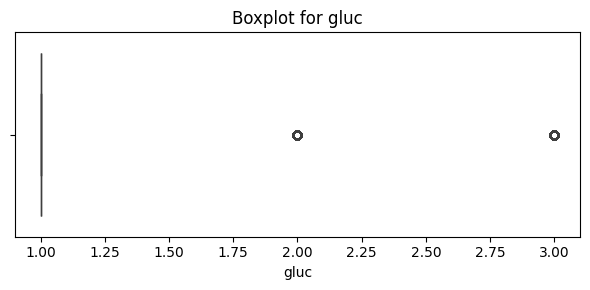

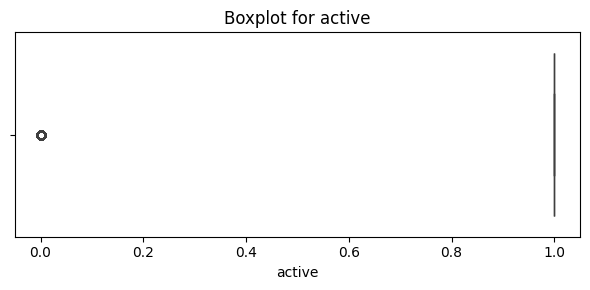

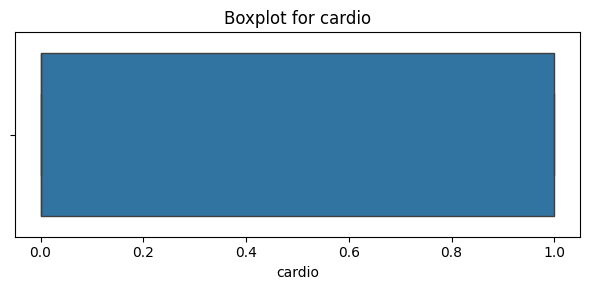

In [16]:
import seaborn as sns 
import matplotlib.pyplot as plt

for col in df.select_dtypes(include='number'):
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot for {col}')
    plt.tight_layout()
    plt.show()


Preprocessing

In [17]:
df= pd.read_csv('cardio_train.csv')

In [18]:
df = df.drop('id', axis=1)

Before

In [19]:
import numpy as np
import pandas as pd

outliers = {}
for col in df.select_dtypes(include=np.number):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.975)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outliers[col] = ((df[col] < low) | (df[col] > high)).sum()


print(pd.DataFrame.from_dict(outliers, orient='index', columns=['Outlier Count']))

             Outlier Count
age(years)               0
gender                   0
height                  92
weight                  13
ap_lo                 1095
ap_hi                  228
cholesterol              0
smoke                    0
alco                     0
gluc                     0
active               13739
cardio                   0


Removing Outliers

In [20]:
cols_for_outlier_removal = ['ap_hi', 'ap_lo', 'weight', 'height']
for col in cols_for_outlier_removal:
    lower_quantile = df[col].quantile(0.025)
    upper_quantile = df[col].quantile(0.975)
    df = df[(df[col] >= lower_quantile) & (df[col] <= upper_quantile)]

print(f"Rows after outlier removal: {df.shape[0]}")

Rows after outlier removal: 60752


After

In [21]:
import numpy as np
import pandas as pd

outliers = {}
for col in df.select_dtypes(include=np.number):
    q1 = df[col].quantile(0.025)
    q3 = df[col].quantile(0.975)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outliers[col] = ((df[col] < low) | (df[col] > high)).sum()


print(pd.DataFrame.from_dict(outliers, orient='index', columns=['Outlier Count']))

             Outlier Count
age(years)               0
gender                   0
height                   0
weight                   0
ap_lo                    0
ap_hi                    0
cholesterol              0
smoke                    0
alco                     0
gluc                     0
active               11938
cardio                   0


In [22]:
df.describe()

,age(years),gender,height,weight,ap_lo,ap_hi,cholesterol,smoke,alco,gluc,active,cardio
count,60752.000000,60752.000000,60752.000000,60752.000000,60752.000000,60752.000000,60752.000000,60752.000000,60752.000000,60752.000000,60752.000000,60752.000000
mean,53.361453,1.347890,164.557183,73.526580,81.153131,126.157065,1.353865,0.085726,0.052179,1.220816,0.803496,0.491902
std,6.745200,0.476305,6.834582,11.701221,8.314405,14.287093,0.672054,0.279961,0.222390,0.567928,0.397357,0.499939
min,30.000000,1.000000,150.000000,52.000000,60.000000,100.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,48.000000,1.000000,160.000000,65.000000,80.000000,120.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,80.000000,120.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,58.000000,2.000000,169.000000,80.850000,90.000000,140.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,65.000000,2.000000,180.000000,107.000000,100.000000,170.000000,3.000000,1.000000,1.000000,3.000000,1.000000,1.000000


Feature Engineering

In [23]:

df['BMI'] = df['weight'] / (df['height']/100)**2


df['map'] = ((2 * df['ap_lo']) + df['ap_hi']) / 3


age_bins = [30, 35, 40, 45, 50, 55, 60, 65]
age_labels = list(range(7))
df['age'] = pd.cut(df['age(years)'], bins=age_bins, labels=age_labels)


bmi_bins = [0, 18.5, 25, 30, 35, 40, np.inf]
bmi_labels = [0, 1, 2, 3, 4, 5] 
df['BMI'] = pd.cut(df['BMI'], bins=bmi_bins, labels=bmi_labels)


map_bins = [0, 70, 80, 90, 100, 110, np.inf]
map_labels = [0, 1, 2, 3, 4, 5]
df['map'] = pd.cut(df['map'], bins=map_bins, labels=map_labels)



In [24]:
df

,age(years),gender,height,weight,ap_lo,ap_hi,cholesterol,smoke,alco,gluc,active,cardio,BMI,map,age
0,50,2,168,62.0,80,110,1,0,0,1,1,0,1,2,3
1,55,1,156,85.0,90,140,3,0,0,1,1,1,3,4,4
2,52,1,165,64.0,70,130,3,0,0,1,0,1,1,2,4
3,48,2,169,82.0,100,150,1,0,0,1,1,1,2,5,3
4,48,1,156,56.0,60,100,1,0,0,1,0,0,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,54,1,172,70.0,90,130,1,0,0,1,1,1,1,4,4
69994,58,1,165,80.0,80,150,1,0,0,1,1,1,2,4,5
69995,53,2,168,76.0,80,120,1,1,0,1,1,0,2,3,4
69998,61,1,163,72.0,80,135,1,0,0,2,0,1,2,3,6


In [25]:
df= df.drop(['age(years)','height', 'weight', 'ap_hi', 'ap_lo'], axis=1)

In [26]:
df

,gender,cholesterol,smoke,alco,gluc,active,cardio,BMI,map,age
0,2,1,0,0,1,1,0,1,2,3
1,1,3,0,0,1,1,1,3,4,4
2,1,3,0,0,1,0,1,1,2,4
3,2,1,0,0,1,1,1,2,5,3
4,1,1,0,0,1,0,0,1,1,3
...,...,...,...,...,...,...,...,...,...,...
69993,1,1,0,0,1,1,1,1,4,4
69994,1,1,0,0,1,1,1,2,4,5
69995,2,1,1,0,1,1,0,2,3,4
69998,1,1,0,0,2,0,1,2,3,6


In [27]:
df.describe()

,gender,cholesterol,smoke,alco,gluc,active,cardio
count,60752.000000,60752.000000,60752.000000,60752.000000,60752.000000,60752.000000,60752.000000
mean,1.347890,1.353865,0.085726,0.052179,1.220816,0.803496,0.491902
std,0.476305,0.672054,0.279961,0.222390,0.567928,0.397357,0.499939
min,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,2.000000,3.000000,1.000000,1.000000,3.000000,1.000000,1.000000


Before

In [28]:
df.isnull().sum()

gender         0
cholesterol    0
smoke          0
alco           0
gluc           0
active         0
cardio         0
BMI            0
map            0
age            4
dtype: int64

Droping Missing Values

In [29]:
df.dropna(inplace=True)

After

In [30]:
df.isnull().sum()

gender         0
cholesterol    0
smoke          0
alco           0
gluc           0
active         0
cardio         0
BMI            0
map            0
age            0
dtype: int64

In [31]:
print("Final Dataframe")
print(df.head())
print("Final Data Shape")
print(df.shape)

Final Dataframe
   gender  cholesterol  smoke  alco  gluc  active  cardio BMI map age
0       2            1      0     0     1       1       0   1   2   3
1       1            3      0     0     1       1       1   3   4   4
2       1            3      0     0     1       0       1   1   2   4
3       2            1      0     0     1       1       1   2   5   3
4       1            1      0     0     1       0       0   1   1   3
Final Data Shape
(60748, 10)


Class distribution:
 cardio
0    30864
1    29884
Name: count, dtype: int64

Class distribution (percentages):
 cardio
0    50.806611
1    49.193389
Name: proportion, dtype: float64


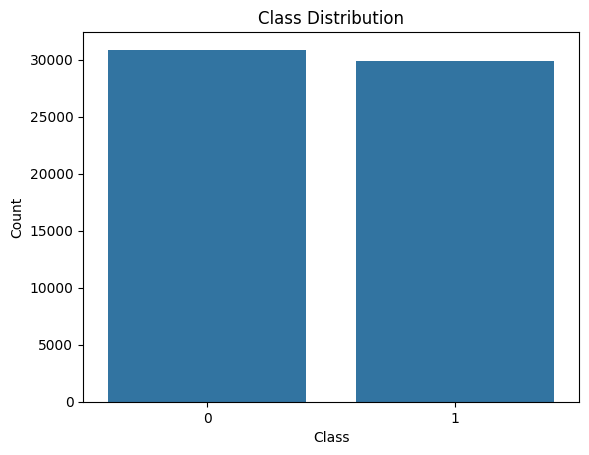

In [32]:
target_column = 'cardio'


class_counts = df[target_column].value_counts()
print("Class distribution:\n", class_counts)

class_percentages = df[target_column].value_counts(normalize=True) * 100
print("\nClass distribution (percentages):\n", class_percentages)


import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df[target_column])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60748 entries, 0 to 69999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   gender       60748 non-null  int64   
 1   cholesterol  60748 non-null  int64   
 2   smoke        60748 non-null  int64   
 3   alco         60748 non-null  int64   
 4   gluc         60748 non-null  int64   
 5   active       60748 non-null  int64   
 6   cardio       60748 non-null  int64   
 7   BMI          60748 non-null  category
 8   map          60748 non-null  category
 9   age          60748 non-null  category
dtypes: category(3), int64(7)
memory usage: 3.9 MB


In [34]:
df.columns

Index(['gender', 'cholesterol', 'smoke', 'alco', 'gluc', 'active', 'cardio',
       'BMI', 'map', 'age'],
      dtype='object')

Clustering

In [ ]:
df_male = df[df['gender'] == 2].copy()
df_female = df[df['gender'] == 1].copy()

k = 2


km_male = KModes(n_clusters=k, init='Huang', n_init=5, random_state=42)
df_male['cluster'] = km_male.fit_predict(df_male)


km_female = KModes(n_clusters=k, init='Huang', n_init=5, random_state=42)
df_female['cluster'] = km_female.fit_predict(df_female)


df_clustered = pd.concat([df_male, df_female], ignore_index=True)
print(f"Data shape after clustering and combining: {df_clustered.shape}")
print("\n--- Data Head after Adding Cluster Feature ---")
print(df_clustered.head())


Preparing Input and Output

In [36]:
X = df_clustered.drop('cardio', axis=1)
y = df_clustered['cardio']
for col in ['age', 'BMI', 'map']:
    X[col] = X[col].astype(int)


Preparing for testing and training

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(48598, 10) (12150, 10) (48598,) (12150,)


XGboost

c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:10:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training accuracy: 0.8780196715914235
Testing accuracy: 0.8683127572016461


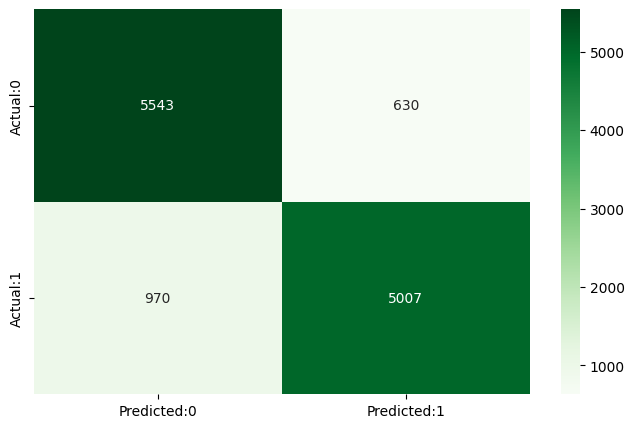

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      6173
           1       0.89      0.84      0.86      5977

    accuracy                           0.87     12150
   macro avg       0.87      0.87      0.87     12150
weighted avg       0.87      0.87      0.87     12150



In [38]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

prediction = xgb.predict(X_test)

training = xgb.score(X_train, y_train)
print('Training accuracy:', training)

accuracy = xgb.score(X_test, y_test)
print('Testing accuracy:', accuracy)

cm = confusion_matrix(y_test, prediction)
conf_matrix = pd.DataFrame(cm, columns=['Predicted:0', 'Predicted:1'], index=['Actual:0', 'Actual:1'])

plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Greens")
plt.show()

print(classification_report(y_test, prediction))


Finding Parameters for XGBoost

In [39]:
'''
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

params =  {
    'max_depth': [4, 5, 6],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 150],
    'subsample': [0.6, 0.7, 0.8],
    
   
}

model = XGBClassifier()
grid = GridSearchCV(estimator=model, param_grid=params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
'''

'\nfrom sklearn.model_selection import GridSearchCV\nfrom xgboost import XGBClassifier\n\nparams =  {\n    \'max_depth\': [4, 5, 6],\n    \'learning_rate\': [0.05, 0.1],\n    \'n_estimators\': [100, 150],\n    \'subsample\': [0.6, 0.7, 0.8],\n    \n   \n}\n\nmodel = XGBClassifier()\ngrid = GridSearchCV(estimator=model, param_grid=params, cv=5, scoring=\'accuracy\')\ngrid.fit(X_train, y_train)\n\nprint("Best parameters:", grid.best_params_)\n'

XGBoost with GridSearch

Training accuracy: 0.8740483147454627
Testing accuracy: 0.8704526748971193


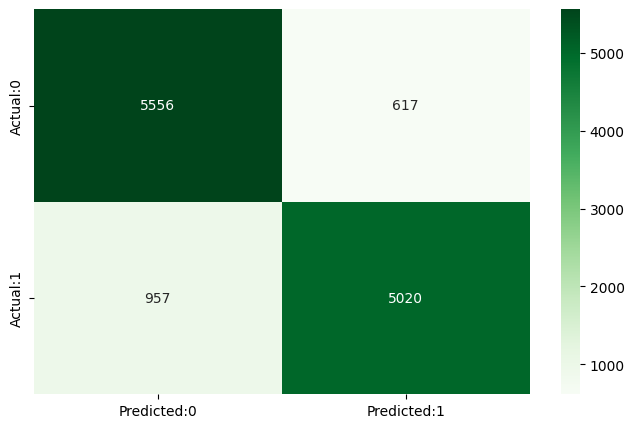

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      6173
           1       0.89      0.84      0.86      5977

    accuracy                           0.87     12150
   macro avg       0.87      0.87      0.87     12150
weighted avg       0.87      0.87      0.87     12150



In [40]:
from xgboost import XGBClassifier

model = XGBClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    subsample=0.7,
    random_state=42
)

model.fit(X_train,y_train)

prediction = model.predict(X_test)

training = model.score(X_train, y_train)
print('Training accuracy:', training)

accuracy = model.score(X_test, y_test)
print('Testing accuracy:', accuracy)

cm = confusion_matrix(y_test, prediction)
conf_matrix = pd.DataFrame(cm, columns=['Predicted:0', 'Predicted:1'], index=['Actual:0', 'Actual:1'])

plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Greens")
plt.show()

print(classification_report(y_test, prediction))


Random Forest

Training accuracy: 0.8822173752006255
Testing accuracy: 0.8654320987654321


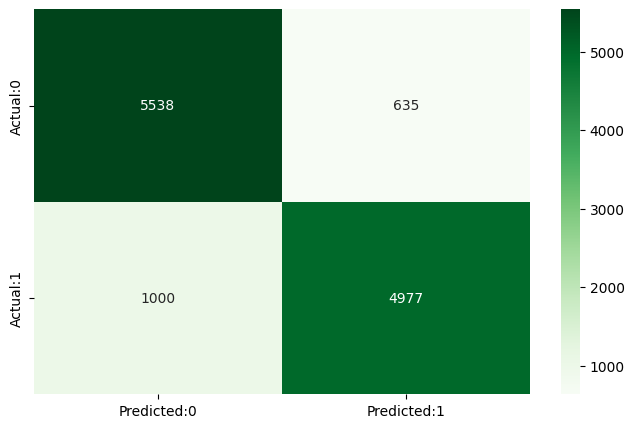

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      6173
           1       0.89      0.83      0.86      5977

    accuracy                           0.87     12150
   macro avg       0.87      0.86      0.87     12150
weighted avg       0.87      0.87      0.87     12150



In [41]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

prediction = rf.predict(X_test)

training = rf.score(X_train, y_train)
print('Training accuracy:', training)

accuracy = rf.score(X_test, y_test)
print('Testing accuracy:', accuracy)

cm = confusion_matrix(y_test, prediction)
conf_matrix = pd.DataFrame(cm, columns=['Predicted:0', 'Predicted:1'], index=['Actual:0', 'Actual:1'])

plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Greens")
plt.show()

print(classification_report(y_test, prediction))


Finding Parameters for Random Forest

In [42]:
'''
from sklearn.model_selection import GridSearchCV
params =  {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False]
   
}

model = RandomForestClassifier()
grid = GridSearchCV(estimator=model, param_grid=params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
'''

'\nfrom sklearn.model_selection import GridSearchCV\nparams =  {\n    \'n_estimators\': [100, 200, 300],\n    \'max_depth\': [None, 10, 20, 30],\n    \'min_samples_split\': [2, 5, 10],\n    \'min_samples_leaf\': [1, 2, 4],\n    \'max_features\': [\'auto\', \'sqrt\', \'log2\'],\n    \'bootstrap\': [True, False]\n   \n}\n\nmodel = RandomForestClassifier()\ngrid = GridSearchCV(estimator=model, param_grid=params, cv=5, scoring=\'accuracy\')\ngrid.fit(X_train, y_train)\n\nprint("Best parameters:", grid.best_params_)\n'

Random Forest with Grid Search

Training accuracy: 0.8719083089839088
Testing accuracy: 0.8669135802469136


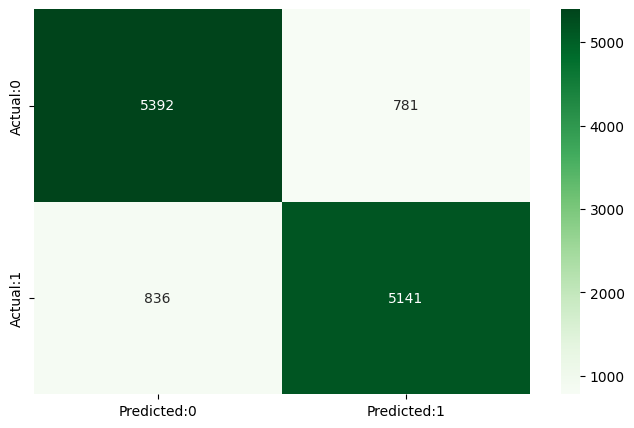

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      6173
           1       0.87      0.86      0.86      5977

    accuracy                           0.87     12150
   macro avg       0.87      0.87      0.87     12150
weighted avg       0.87      0.87      0.87     12150



In [43]:
rf = RandomForestClassifier( n_estimators=300,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=42)
rf.fit(X_train, y_train)

prediction = rf.predict(X_test)

training = rf.score(X_train, y_train)
print('Training accuracy:', training)

accuracy = rf.score(X_test, y_test)
print('Testing accuracy:', accuracy)

cm = confusion_matrix(y_test, prediction)
conf_matrix = pd.DataFrame(cm, columns=['Predicted:0', 'Predicted:1'], index=['Actual:0', 'Actual:1'])

plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Greens")
plt.show()

print(classification_report(y_test, prediction))


KNN

Training accuracy: 0.8620519362936746
Testing accuracy: 0.8473251028806584


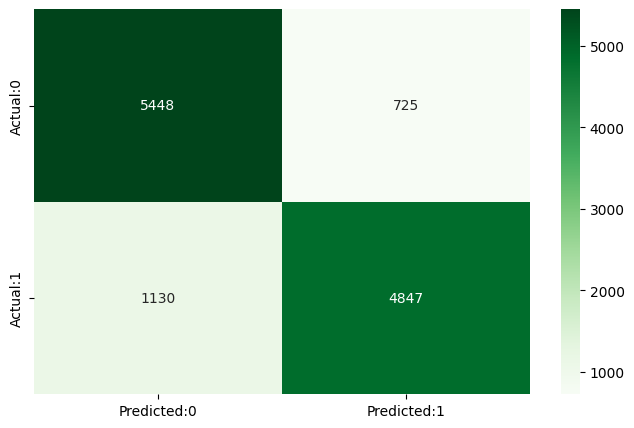

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      6173
           1       0.87      0.81      0.84      5977

    accuracy                           0.85     12150
   macro avg       0.85      0.85      0.85     12150
weighted avg       0.85      0.85      0.85     12150



In [44]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

prediction = knn.predict(X_test)

training = knn.score(X_train, y_train)
print('Training accuracy:', training)

accuracy = knn.score(X_test, y_test)
print('Testing accuracy:', accuracy)

cm = confusion_matrix(y_test, prediction)
conf_matrix = pd.DataFrame(cm, columns=['Predicted:0', 'Predicted:1'], index=['Actual:0', 'Actual:1'])

plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Greens")
plt.show()

print(classification_report(y_test, prediction))


Finding parameters values for KNN with Grid search

In [45]:
'''
from sklearn.model_selection import GridSearchCV
params =  {
     'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
   
}

model = KNeighborsClassifier()
grid = GridSearchCV(estimator=model, param_grid=params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
'''

'\nfrom sklearn.model_selection import GridSearchCV\nparams =  {\n     \'n_neighbors\': [3, 5, 7, 9, 11],\n    \'weights\': [\'uniform\', \'distance\'],\n    \'metric\': [\'euclidean\', \'manhattan\', \'minkowski\'],\n    \'p\': [1, 2]  # 1 = Manhattan, 2 = Euclidean\n   \n}\n\nmodel = KNeighborsClassifier()\ngrid = GridSearchCV(estimator=model, param_grid=params, cv=5, scoring=\'accuracy\')\ngrid.fit(X_train, y_train)\n\nprint("Best parameters:", grid.best_params_)\n'

KNN with Grid Search

Training accuracy: 0.8620519362936746
Testing accuracy: 0.8473251028806584


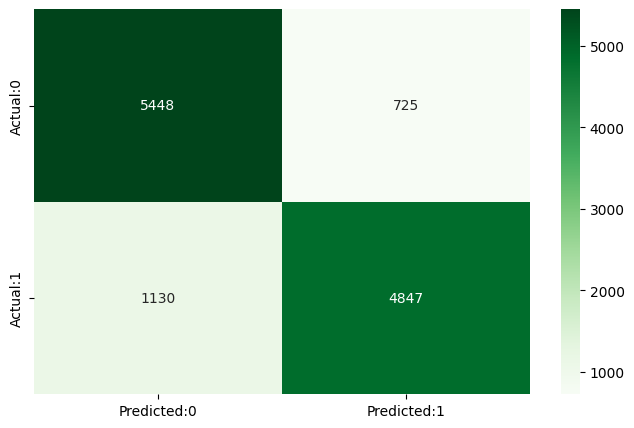

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      6173
           1       0.87      0.81      0.84      5977

    accuracy                           0.85     12150
   macro avg       0.85      0.85      0.85     12150
weighted avg       0.85      0.85      0.85     12150



In [46]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5,
                         
    weights='uniform',
    metric='euclidean',
    p= 1)

knn.fit(X_train, y_train)

prediction = knn.predict(X_test)

training = knn.score(X_train, y_train)
print('Training accuracy:', training)

accuracy = knn.score(X_test, y_test)
print('Testing accuracy:', accuracy)

cm = confusion_matrix(y_test, prediction)
conf_matrix = pd.DataFrame(cm, columns=['Predicted:0', 'Predicted:1'], index=['Actual:0', 'Actual:1'])

plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Greens")
plt.show()

print(classification_report(y_test, prediction))
